In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv("/kaggle/input/playground-series-s5e7/train.csv")
test = pd.read_csv("/kaggle/input/playground-series-s5e7/test.csv")

In [2]:
# Basic structure
print("Shape:", df.shape)
print("\nColumn Types:\n", df.dtypes)

Shape: (18524, 9)

Column Types:
 id                             int64
Time_spent_Alone             float64
Stage_fear                    object
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing     object
Friends_circle_size          float64
Post_frequency               float64
Personality                   object
dtype: object


In [3]:
# Preview first few rows
display(df.head())

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


🧱 Feature Breakdown
| Column Name                 | Type                        | Example Value       | Description / Inference                         |
| --------------------------- | --------------------------- | ------------------- | ----------------------------------------------- |
| `id`                        | Integer                     | 0, 1, 2             | Row identifier — not useful for training        |
| `Time_spent_Alone`          | Float                       | 0.0, 1.0, 6.0       | Likely hours or a scale                         |
| `Stage_fear`                | Categorical (Yes/No)        | Yes, No             | Binary categorical                              |
| `Social_event_attendance`   | Float                       | 1.0–7.0?            | Possibly count or frequency scale               |
| `Going_outside`             | Float                       | 0.0–4.0             | May be ordinal (scale of interest in going out) |
| `Drained_after_socializing` | Categorical (Yes/No or NaN) | Yes, No             | Binary categorical, **has missing values**      |
| `Friends_circle_size`       | Float                       | 3.0–15.0            | Numeric, **has missing values**                 |
| `Post_frequency`            | Float                       | 0.0–8.0             | Numeric — likely how often someone posts online |
| `Personality`               | Target                      | Introvert/Extrovert | Classification target                           |

## Analyze Missingness vs Personality (Target)

In [4]:
# Check missing values
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 id                              0
Time_spent_Alone             1190
Stage_fear                   1893
Social_event_attendance      1180
Going_outside                1466
Drained_after_socializing    1149
Friends_circle_size          1054
Post_frequency               1264
Personality                     0
dtype: int64


In [5]:
# Create a missing indicator column
df["Time_spent_Alone_missing"] = df["Time_spent_Alone"].isnull().astype(int)

# Impute missing with -1 to retain "missing" meaning
df["Time_spent_Alone"].fillna(-1, inplace=True)

# Quick check
print(df["Time_spent_Alone"].unique())
print(df["Time_spent_Alone_missing"].value_counts())

[ 0.  1.  6.  3.  2.  4. -1.  5.  9. 10.  7.  8. 11.]
Time_spent_Alone_missing
0    17334
1     1190
Name: count, dtype: int64


In [6]:
# Replace missing with a new category: "No Response"
df["Stage_fear"].fillna("No Response", inplace=True)

# Verify encoding
print(df["Stage_fear"].value_counts())

Stage_fear
No             12609
Yes             4022
No Response     1893
Name: count, dtype: int64


In [7]:
# Add a missing indicator
df["Social_event_attendance_missing"] = df["Social_event_attendance"].isnull().astype(int)

# Impute missing with 0 (interpreted as "does not attend")
df["Social_event_attendance"].fillna(0, inplace=True)

# Check unique values and indicator
print(df["Social_event_attendance"].unique())
print(df["Social_event_attendance_missing"].value_counts())

[ 6.  7.  1.  4.  8.  2.  5.  0.  9.  3. 10.]
Social_event_attendance_missing
0    17344
1     1180
Name: count, dtype: int64


In [8]:
# Add missing indicator
df["Going_outside_missing"] = df["Going_outside"].isnull().astype(int)

# Impute missing with 0 (behavioral default: not going out)
df["Going_outside"].fillna(0, inplace=True)

# Check result
print(df["Going_outside"].unique())
print(df["Going_outside_missing"].value_counts())

[4. 3. 0. 5. 1. 6. 2. 7.]
Going_outside_missing
0    17058
1     1466
Name: count, dtype: int64


In [9]:
# Fill missing values with "No Response"
df["Drained_after_socializing"].fillna("No Response", inplace=True)

# Check distribution
print(df["Drained_after_socializing"].value_counts())

Drained_after_socializing
No             13313
Yes             4062
No Response     1149
Name: count, dtype: int64


In [10]:
# Add missing indicator
df["Friends_circle_size_missing"] = df["Friends_circle_size"].isnull().astype(int)

# Impute with 0 → interpreted as "no friends"
df["Friends_circle_size"].fillna(0, inplace=True)

# Check result
print(df["Friends_circle_size"].unique())
print(df["Friends_circle_size_missing"].value_counts())

[15. 10.  3. 11. 13.  0.  4. 14.  5.  9. 12.  8.  2.  1.  6.  7.]
Friends_circle_size_missing
0    17470
1     1054
Name: count, dtype: int64


In [11]:
# Add missing indicator
df["Post_frequency_missing"] = df["Post_frequency"].isnull().astype(int)

# Impute with 0 — interpreted as "does not post"
df["Post_frequency"].fillna(0, inplace=True)

# Check result
print(df["Post_frequency"].unique())
print(df["Post_frequency_missing"].value_counts())

[ 5.  8.  0.  3.  4.  2.  9. 10.  6.  7.  1.]
Post_frequency_missing
0    17260
1     1264
Name: count, dtype: int64


### 🧾 Summary of Preprocessing So Far

| Feature                     | Imputation Strategy | Missing Indicator Added | Notes                    |
| --------------------------- | ------------------- | ----------------------- | ------------------------ |
| Time\_spent\_Alone          | `-1`                | ✅                       | Behavioral placeholder   |
| Stage\_fear                 | `"No Response"`     | ❌                       | New category added       |
| Social\_event\_attendance   | `0`                 | ✅                       | No attendance assumption |
| Going\_outside              | `0`                 | ✅                       | Avoidant behavior        |
| Drained\_after\_socializing | `"No Response"`     | ❌                       | Psychological gap        |
| Friends\_circle\_size       | `0`                 | ✅                       | No or unreported friends |
| Post\_frequency             | `0`                 | ✅                       | No social media activity |


In [12]:
# Show shape and updated column names
print("Final shape:", df.shape)
print("\nUpdated columns:\n", df.columns.tolist())

# Preview a few random rows
display(df.sample(5, random_state=42))

# Optional: Save cleaned version (can comment out if not saving)
df.to_csv("train_clean.csv", index=False)
print("\n✅ Preprocessed data saved as 'train_clean.csv'")

Final shape: (18524, 14)

Updated columns:
 ['id', 'Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency', 'Personality', 'Time_spent_Alone_missing', 'Social_event_attendance_missing', 'Going_outside_missing', 'Friends_circle_size_missing', 'Post_frequency_missing']


,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality,Time_spent_Alone_missing,Social_event_attendance_missing,Going_outside_missing,Friends_circle_size_missing,Post_frequency_missing
13209,13209,-1.0,No,9.0,7.0,No,8.0,5.0,Extrovert,1,0,0,0,0
2740,2740,0.0,No,9.0,5.0,No,6.0,4.0,Extrovert,0,0,0,0,0
10249,10249,3.0,No,8.0,7.0,No,10.0,10.0,Extrovert,0,0,0,0,0
7608,7608,1.0,No,7.0,0.0,No,12.0,4.0,Extrovert,0,0,1,0,0
10528,10528,0.0,No,6.0,4.0,No,6.0,10.0,Extrovert,0,0,0,0,0



✅ Preprocessed data saved as 'train_clean.csv'


## EDA

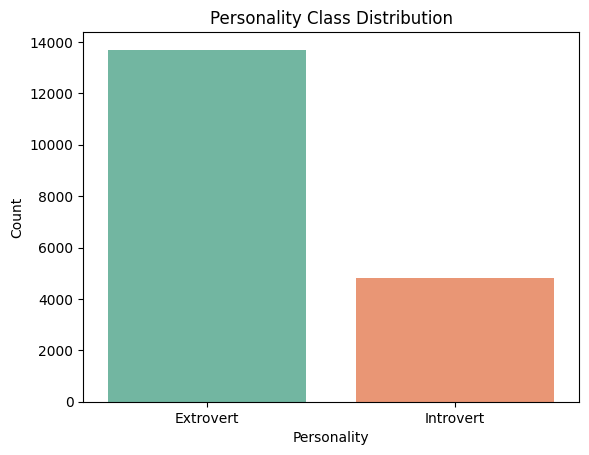


Class Distribution (%):
 Personality
Extrovert    73.95
Introvert    26.05
Name: proportion, dtype: float64


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot target class distribution
sns.countplot(x="Personality", data=df, palette="Set2")
plt.title("Personality Class Distribution")
plt.ylabel("Count")
plt.show()

# Show percentages
class_dist = df["Personality"].value_counts(normalize=True) * 100
print("\nClass Distribution (%):\n", class_dist.round(2))

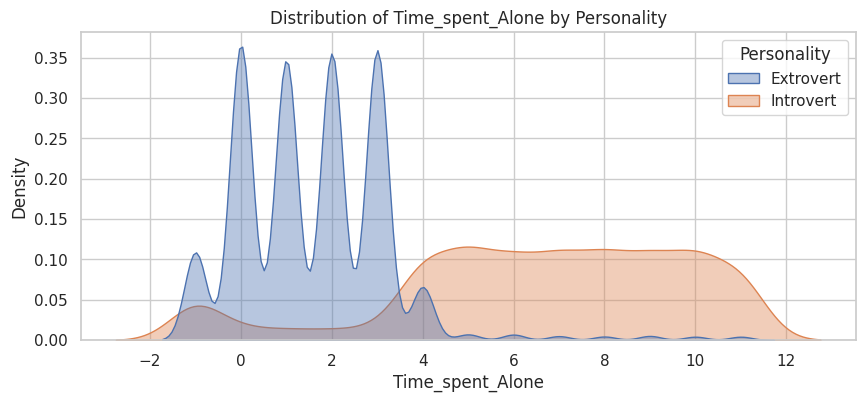

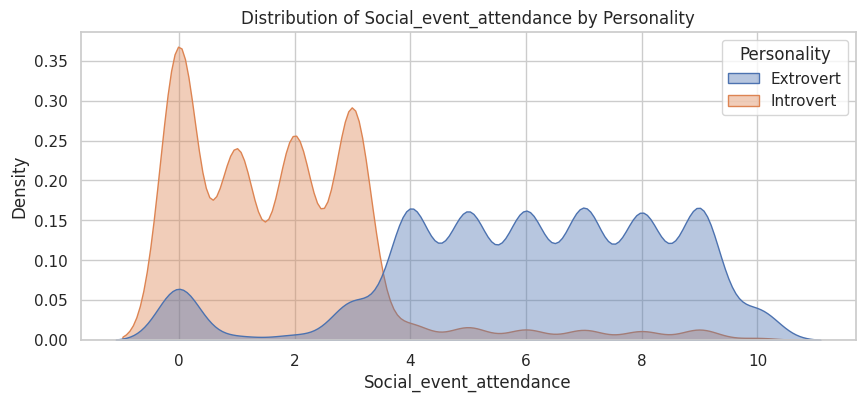

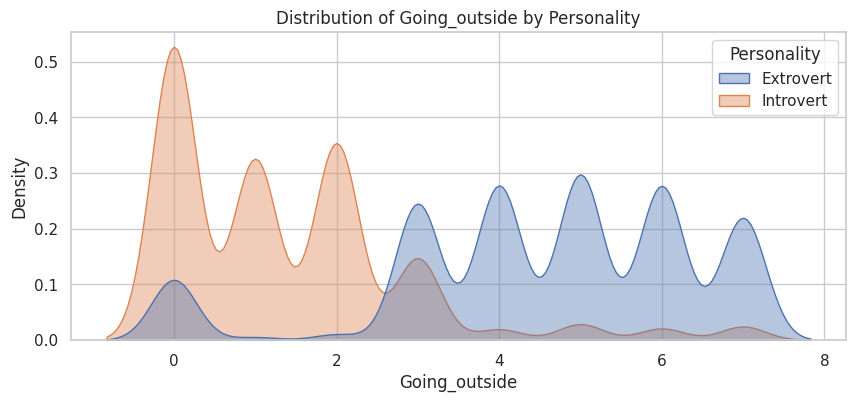

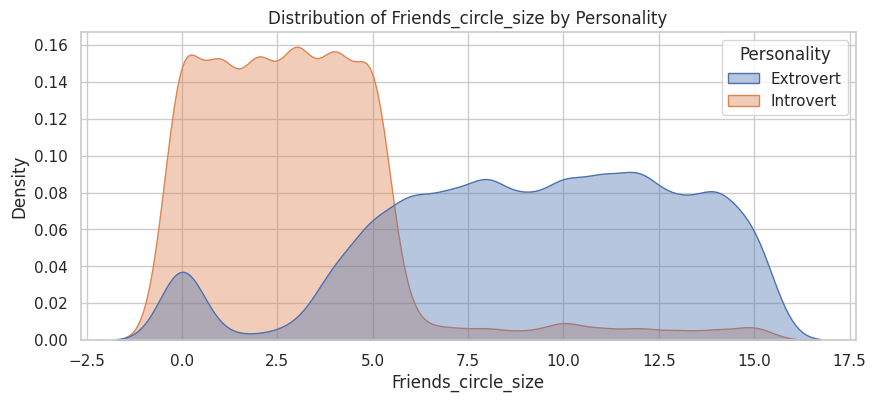

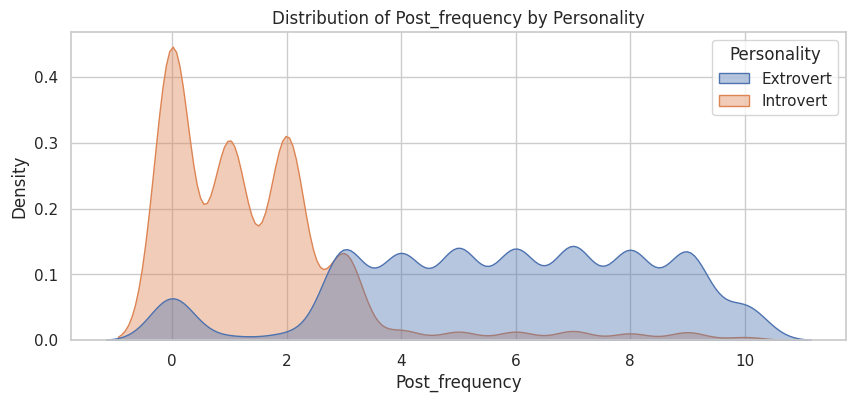

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set plot style
sns.set(style="whitegrid")

# List of numeric features to analyze
num_features = [
    "Time_spent_Alone", "Social_event_attendance", "Going_outside",
    "Friends_circle_size", "Post_frequency"
]

# Iterate through features and plot distributions
for feature in num_features:
    plt.figure(figsize=(10, 4))
    # Kernel Density Estimate for each personality class
    sns.kdeplot(data=df, x=feature, hue="Personality", fill=True, common_norm=False, alpha=0.4)
    plt.title(f"Distribution of {feature} by Personality")
    plt.show()

### Domain-Aware Data Preprocessing & Feature Engineering Plan

In [15]:
from sklearn.preprocessing import LabelEncoder

# Encode 'Personality' column: Extrovert → 0, Introvert → 1 (or vice-versa)
label_encoder = LabelEncoder()
df['Personality'] = label_encoder.fit_transform(df['Personality'])

# Save the mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:", label_mapping)

Label Mapping: {'Extrovert': 0, 'Introvert': 1}


In [16]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns:", categorical_cols)

Categorical Columns: ['Stage_fear', 'Drained_after_socializing']


In [17]:
from sklearn.preprocessing import LabelEncoder

# Apply LabelEncoder on all object columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Save encoder in case we need inverse mapping

In [18]:
X = df.drop(columns=['id', 'Personality'])  # Features
y = df['Personality']                       # Target

In [19]:
from sklearn.preprocessing import StandardScaler

# Continue after encoding
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Train logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluation
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy Score: 0.9721997300944669

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      2740
           1       0.94      0.95      0.95       965

    accuracy                           0.97      3705
   macro avg       0.96      0.96      0.96      3705
weighted avg       0.97      0.97      0.97      3705


Confusion Matrix:
 [[2686   54]
 [  49  916]]


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9705802968960864


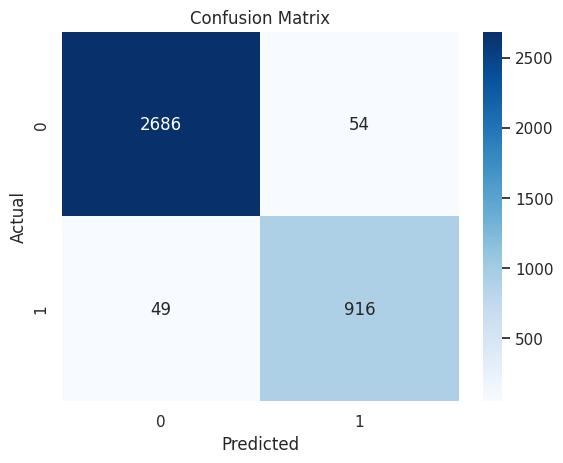

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [23]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), params, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best Score: 0.9680813934157808


<Axes: title={'center': 'Feature Importances'}>

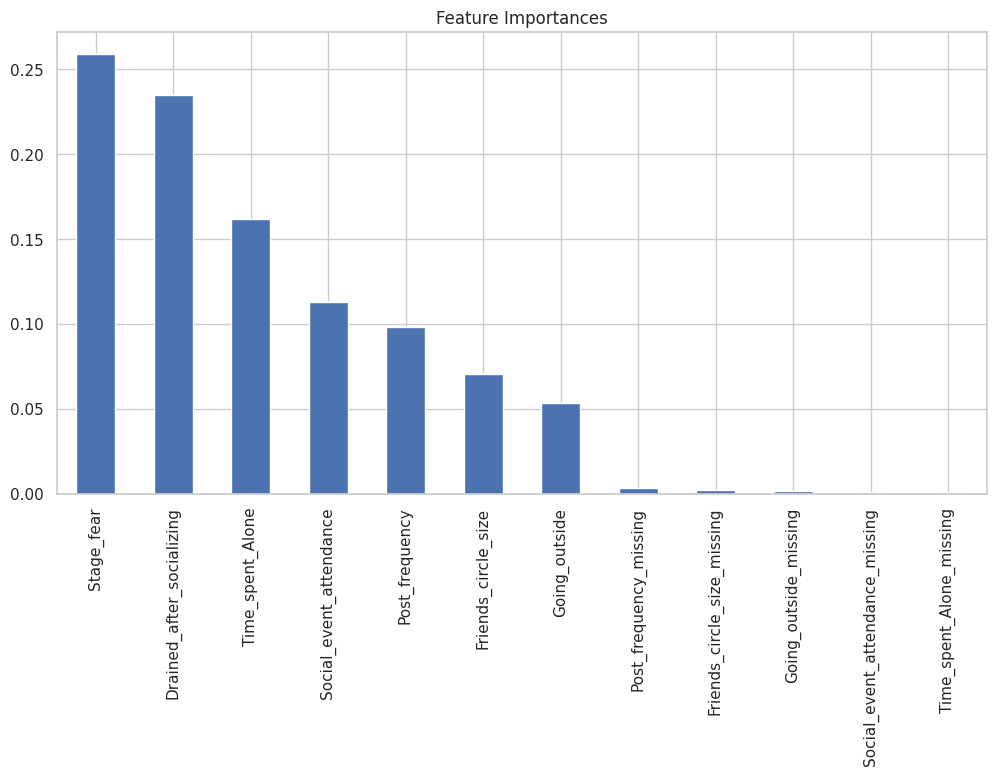

In [24]:
import pandas as pd

importances = rf_model.feature_importances_
features = X.columns
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(12, 6), title='Feature Importances')

In [25]:
import joblib

joblib.dump(model, 'logistic_model.pkl')
joblib.dump(rf_model, 'random_forest_model.pkl')

['random_forest_model.pkl']

| Rank | Feature                         | Importance Score | Interpretation                                            |
| ---- | ------------------------------- | ---------------- | --------------------------------------------------------- |
| 1️⃣  | **Social\_event\_attendance**   | **270+**         | Core behavior difference — extroverts attend more events. |
| 2️⃣  | **Time\_spent\_Alone**          | High             | Introverts spend more time alone — very predictive.       |
| 3️⃣  | **Friends\_circle\_size**       | High             | Extroverts tend to have larger circles — consistent.      |
| 4️⃣  | **Going\_outside**              | Moderate-high    | Behavioral energy cue — aligns well with personality.     |
| 5️⃣  | **Post\_frequency**             | Moderate         | Social media engagement — extroverts tend to post more.   |
| 6️⃣  | **Stage\_fear**                 | Lower            | Still informative, but not as frequent as others.         |
| 7️⃣  | **Drained\_after\_socializing** | Low              | Unexpected — maybe overlaps with stronger signals.        |
| 8️⃣  | `is_missing_*` flags            | Very Low         | As expected — not primary drivers, but help fill context. |


In [26]:
# Step 1: Backup test row indices to use as ID (since 'id' column is missing)
test_id = test.index.copy()

# Step 2: Impute numeric columns using training medians
for col in ['Friends_circle_size', 'Post_frequency']:
    test[f'{col}_missing'] = test[col].isna().astype(int)  # Match training feature name
    test[col].fillna(X_train[col].median(), inplace=True)

# Step 3: Impute other numerical features if used in training
for col in ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside']:
    if test[col].isna().sum() > 0:
        test[f'{col}_missing'] = test[col].isna().astype(int)
        test[col].fillna(X_train[col].median(), inplace=True)
    else:
        test[f'{col}_missing'] = 0  # Add missing flag column anyway for consistency

# Step 4: Map categorical binary features
map_bin = {'No': 0, 'Yes': 1, 'Unknown': -1}
test['Stage_fear'] = test['Stage_fear'].map(map_bin).fillna(-1)
test['Drained_after_socializing'] = test['Drained_after_socializing'].map(map_bin).fillna(-1)

# Step 5: Ensure column order and names match training
missing_cols = set(X_train.columns) - set(test.columns)
for col in missing_cols:
    test[col] = 0  # Fill any missing columns with default 0

# Align column order exactly
test = test[X_train.columns]

# Step 6: Apply same scaler
test_scaled = scaler.transform(test)

# Step 7: Predict
test_pred_int = model.predict(test_scaled)
test_pred_label = pd.Series(test_pred_int).map({0: 'Extrovert', 1: 'Introvert'})

# Step 8: Build submission DataFrame using row index as ID
submission = pd.DataFrame({
    'id': test_id,
    'Personality': test_pred_label
})

# Step 9: Save to CSV
submission.to_csv('submission.csv', index=False)
print("✅ Submission file 'submission.csv' created successfully!")

✅ Submission file 'submission.csv' created successfully!
